In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

In [221]:
print(data.describe())


                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.066207   456.098091  ..

In [222]:
target_corr=abs(data.corr(method="spearman",numeric_only=True)["SalePrice"]).sort_values(ascending=False)
print(target_corr)
#спирман для устойчивости к выбрасам + любая монотонная зависимость


SalePrice        1.000000
OverallQual      0.809829
GrLivArea        0.731310
GarageCars       0.690711
YearBuilt        0.652682
GarageArea       0.649379
FullBath         0.635957
TotalBsmtSF      0.602725
GarageYrBlt      0.593788
1stFlrSF         0.575408
YearRemodAdd     0.571159
TotRmsAbvGrd     0.532586
Fireplaces       0.519247
OpenPorchSF      0.477561
LotArea          0.456461
MasVnrArea       0.421309
LotFrontage      0.409076
WoodDeckSF       0.353802
HalfBath         0.343008
BsmtFinSF1       0.301871
2ndFlrSF         0.293598
BedroomAbvGr     0.234907
BsmtFullBath     0.225125
EnclosedPorch    0.218394
BsmtUnfSF        0.185197
KitchenAbvGr     0.164826
OverallCond      0.129325
ScreenPorch      0.100070
MoSold           0.069432
LowQualFinSF     0.067719
3SsnPorch        0.065440
MiscVal          0.062727
PoolArea         0.058453
BsmtFinSF2       0.038806
YrSold           0.029899
Id               0.018546
BsmtHalfBath     0.012189
MSSubClass       0.007192
Name: SalePr

In [ ]:
# НОВЫЕ ПРИЗНАКИ 

# Общая площадь
data['TotalSF'] = data['GrLivArea'] + data['TotalBsmtSF']
test['TotalSF'] = test['GrLivArea'] + test['TotalBsmtSF']

# Возраст дома и возраст после ремонта
data['HouseAge'] = data['YrSold'] - data['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

data['RemodAge'] = data['YrSold'] - data['YearRemodAdd']
test['RemodAge'] = test['YrSold'] - test['YearRemodAdd']

# Взаимодействие качества и площади
data['QualArea'] = data['OverallQual'] * data['GrLivArea']
test['QualArea'] = test['OverallQual'] * test['GrLivArea']

# Бинарные признаки наличия
data['HasBsmt'] = (data['TotalBsmtSF'] > 0).astype(int)
test['HasBsmt'] = (test['TotalBsmtSF'] > 0).astype(int)

data['HasGarage'] = (data['GarageCars'] > 0).astype(int)
test['HasGarage'] = (test['GarageCars'] > 0).astype(int)

print(" Новые признаки добавлены")
print(f"Размер data: {data.shape}, test: {test.shape}")

✅ Новые признаки добавлены
Размер data: (1460, 87), test: (1459, 86)


In [224]:
data.drop(["BsmtHalfBath","Id","YrSold","BsmtFinSF2","PoolArea","MiscVal","3SsnPorch","LowQualFinSF"],axis=1, inplace=True)
test.drop(["BsmtHalfBath","Id","YrSold","BsmtFinSF2","PoolArea","MiscVal","3SsnPorch","LowQualFinSF"],axis=1, inplace=True)

In [225]:
corr=abs(data.corr(numeric_only=True, method="spearman"))
print(corr)

               MSSubClass  LotFrontage   LotArea  OverallQual  OverallCond  \
MSSubClass       1.000000     0.314265  0.269570     0.108065     0.071770   
LotFrontage      0.314265     1.000000  0.649633     0.254952     0.083242   
LotArea          0.269570     0.649633  1.000000     0.233303     0.046912   
OverallQual      0.108065     0.254952  0.233303     1.000000     0.177521   
OverallCond      0.071770     0.083242  0.046912     0.177521     1.000000   
YearBuilt        0.035848     0.194510  0.103385     0.647392     0.416964   
YearRemodAdd     0.006802     0.116772  0.075158     0.557723     0.041464   
MasVnrArea       0.025035     0.258906  0.177539     0.413500     0.179187   
BsmtFinSF1       0.107629     0.154014  0.171995     0.132957     0.011087   
BsmtUnfSF        0.117603     0.119436  0.077830     0.272939     0.128270   
TotalBsmtSF      0.318897     0.386206  0.366197     0.459915     0.217375   
1stFlrSF         0.278318     0.427678  0.443858     0.408730   

In [226]:
corr=corr.unstack()
corr=corr[(corr>0.6)&(corr<1.0)].sort_values(ascending=False)
print(corr)

YearBuilt     HouseAge        0.996348
HouseAge      YearBuilt       0.996348
RemodAge      YearRemodAdd    0.990924
YearRemodAdd  RemodAge        0.990924
QualArea      GrLivArea       0.925565
GrLivArea     QualArea        0.925565
YearBuilt     GarageYrBlt     0.890546
GarageYrBlt   YearBuilt       0.890546
HouseAge      GarageYrBlt     0.885931
GarageYrBlt   HouseAge        0.885931
TotalSF       QualArea        0.870694
QualArea      TotalSF         0.870694
TotalSF       GrLivArea       0.869057
GrLivArea     TotalSF         0.869057
GarageCars    GarageArea      0.853317
GarageArea    GarageCars      0.853317
SalePrice     QualArea        0.852943
QualArea      SalePrice       0.852943
              OverallQual     0.851015
OverallQual   QualArea        0.851015
TotalBsmtSF   1stFlrSF        0.829292
1stFlrSF      TotalBsmtSF     0.829292
TotRmsAbvGrd  GrLivArea       0.827874
GrLivArea     TotRmsAbvGrd    0.827874
TotalSF       SalePrice       0.814984
SalePrice     TotalSF    

In [227]:
data.drop(["GarageYrBlt","GarageArea", "1stFlrSF","TotRmsAbvGrd"],axis=1, inplace=True)
test.drop(["GarageYrBlt","GarageArea", "1stFlrSF","TotRmsAbvGrd"],axis=1, inplace=True)

In [228]:
pd.set_option('display.max_rows', None)
print(data.dtypes)


MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
Street               str
Alley                str
LotShape             str
LandContour          str
Utilities            str
LotConfig            str
LandSlope            str
Neighborhood         str
Condition1           str
Condition2           str
BldgType             str
HouseStyle           str
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle            str
RoofMatl             str
Exterior1st          str
Exterior2nd          str
MasVnrType           str
MasVnrArea       float64
ExterQual            str
ExterCond            str
Foundation           str
BsmtQual             str
BsmtCond             str
BsmtExposure         str
BsmtFinType1         str
BsmtFinSF1         int64
BsmtFinType2         str
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating              str
HeatingQC            str
CentralAir           str


In [229]:

col_to_fill=['MasVnrArea']

data[col_to_fill] = np.nan_to_num(data[col_to_fill].values, nan=0.0)
col_to_fill=['MasVnrArea']

test[col_to_fill] = np.nan_to_num(test[col_to_fill].values, nan=0.0)

In [230]:
data['LotFrontage'] = data['LotFrontage'].fillna(data['LotFrontage'].median())
test['LotFrontage'] = test['LotFrontage'].fillna(data['LotFrontage'].median())

In [231]:
col_to_fill=['Alley','MasVnrType','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','Electrical','FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature']

data[col_to_fill] = data[col_to_fill].fillna("None")
test[col_to_fill] = test[col_to_fill].fillna("None")

In [232]:
neighborhood_medians = data.groupby('Neighborhood')['SalePrice'].median()
data['Neighborhood']=data['Neighborhood'].map(neighborhood_medians)
test['Neighborhood']=test['Neighborhood'].map(neighborhood_medians)

In [233]:
MSZoning_medians = data.groupby('MSZoning')['SalePrice'].median()
data['MSZoning']=data['MSZoning'].map(MSZoning_medians)
test['MSZoning']=test['MSZoning'].map(MSZoning_medians)

MSSubClass_medians = data.groupby('MSSubClass')['SalePrice'].median()
data['MSSubClass']=data['MSSubClass'].map(MSSubClass_medians)
test['MSSubClass']=test['MSSubClass'].map(MSSubClass_medians)

Exterior1st_medians = data.groupby('Exterior1st')['SalePrice'].median()
data['Exterior1st']=data['Exterior1st'].map(Exterior1st_medians)
test['Exterior1st']=test['Exterior1st'].map(Exterior1st_medians)

Exterior2nd_medians = data.groupby('Exterior2nd')['SalePrice'].median()
data['Exterior2nd']=data['Exterior2nd'].map(Exterior2nd_medians)
test['Exterior2nd']=test['Exterior2nd'].map(Exterior2nd_medians)



In [234]:
from sklearn.preprocessing import OneHotEncoder
enc=OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cols=['Street','Alley','LotShape','LandContour','Utilities','LotConfig','LandSlope','Condition1','Condition2','BldgType','HouseStyle','RoofStyle','RoofMatl','MasVnrType','ExterQual','ExterCond','Foundation','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','Heating','HeatingQC','CentralAir','Electrical','KitchenQual','Functional','FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','PavedDrive','PoolQC','Fence','MiscFeature','SaleType','SaleCondition']
enc.fit(data[cols])
data_ohe=enc.transform(data[cols])
test_ohe=enc.transform(test[cols])

enc_cols=enc.get_feature_names_out(cols)
data_enc=pd.DataFrame(data_ohe, columns=enc_cols, index=data.index)
test_enc=pd.DataFrame(test_ohe, columns=enc_cols, index=test.index)

data=data.drop(columns=cols)
test=test.drop(columns=cols)

data=pd.concat([data,data_enc],axis=1)
test=pd.concat([test,test_enc],axis=1)

In [235]:
miss = test.isnull().sum()
print(miss[miss > 0])
for col in miss[miss > 0].index:
    test[col] = test[col].fillna(data[col].median())

MSSubClass      1
MSZoning        4
Exterior1st     1
Exterior2nd     1
BsmtFinSF1      1
BsmtUnfSF       1
TotalBsmtSF     1
BsmtFullBath    2
GarageCars      1
TotalSF         1
dtype: int64


In [236]:
print(data.select_dtypes(include='str').columns)   # должно быть пусто
print(data.shape, test.shape)                       # колонки совпадают (у data +1 за счёт SalePrice)
print(data.isnull().sum().sum(), test.isnull().sum().sum())  # оба нуля

Index([], dtype='str')
(1460, 242) (1459, 241)
0 0


In [237]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
model_lin=LinearRegression()

X=data.drop(columns=['SalePrice'])
Y=np.log(data['SalePrice'])
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)


scaler=StandardScaler()
X_train_sc=scaler.fit_transform(X_train)# стандартизация для равноправности признаков
X_val_sc=scaler.transform(X_val)
model_lin.fit(X_train_sc,Y_train)
pred_train = model_lin.predict(X_train_sc)
pred_val   = model_lin.predict(X_val_sc)

In [238]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error

def score(y, pred):
    mae=mean_absolute_error(np.exp(y),np.exp(pred))
    rmse=np.sqrt(mean_squared_error(np.exp(y),np.exp(pred)))
    r2=r2_score(y,pred)
    print("mae ",mae,"\n rmse ", rmse,"\n r2 ",r2)

def rmsle_score(y_true, y_pred):
    # RMSLE работает только с положительными значениями
    y_true = np.clip(y_true, 0, None)
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))
score(Y_train, pred_train)
score(Y_val,pred_val)
print(f"RMSLE: {rmsle_score(np.exp(Y_train), np.exp(pred_train))}")
print(f"RMSLE: {rmsle_score(np.exp(Y_val), np.exp(pred_val))}")

mae  11863.12706093491 
 rmse  18658.754652675787 
 r2  0.9393061920849293
mae  15704.988003987895 
 rmse  23459.05187074034 
 r2  0.9057686082833558
RMSLE: 0.09618883738851172
RMSLE: 0.13260662397825612


In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# RidgeCV по умолчанию использует LOOCV (эффективно для небольших данных)
ridge = RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 100.0, 500.0], cv=5)
ridge.fit(X_train_sc, Y_train)
print(f"Ridge: лучший alpha = {ridge.alpha_}")

pred_train_ridge = ridge.predict(X_train_sc)
pred_val_ridge = ridge.predict(X_val_sc)

print("\n=== Ridge train ===")
score(Y_train, pred_train_ridge)
print(f"RMSLE: {rmsle_score(np.exp(Y_train), np.exp(pred_train_ridge)):.4f}")

print("\n=== Ridge val ===")
score(Y_val, pred_val_ridge)
print(f"RMSLE: {rmsle_score(np.exp(Y_val), np.exp(pred_val_ridge)):.4f}")

#LASSO (для сравнения)
lasso = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1.0], 
                cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train_sc, Y_train)
print(f"\nLasso: лучший alpha = {lasso.alpha_}")
print(f"Кол-во ненулевых признаков: {np.sum(lasso.coef_ != 0)} из {len(lasso.coef_)}")

pred_val_lasso = lasso.predict(X_val_sc)
print("\n=== Lasso val ===")
score(Y_val, pred_val_lasso)
print(f"RMSLE: {rmsle_score(np.exp(Y_val), np.exp(pred_val_lasso)):.4f}")

Ridge: лучший alpha = 500.0

=== Ridge train ===
mae  14045.323486362544 
 rmse  22110.63654431583 
 r2  0.9198935311480055
RMSLE: 0.1105

=== Ridge val ===
mae  16049.140353212337 
 rmse  24922.731819925542 
 r2  0.8918384008003187
RMSLE: 0.1421

Lasso: лучший alpha = 0.01
Кол-во ненулевых признаков: 50 из 241

=== Lasso val ===
mae  15258.471257541181 
 rmse  23676.075323649013 
 r2  0.9093057932078659
RMSLE: 0.1301


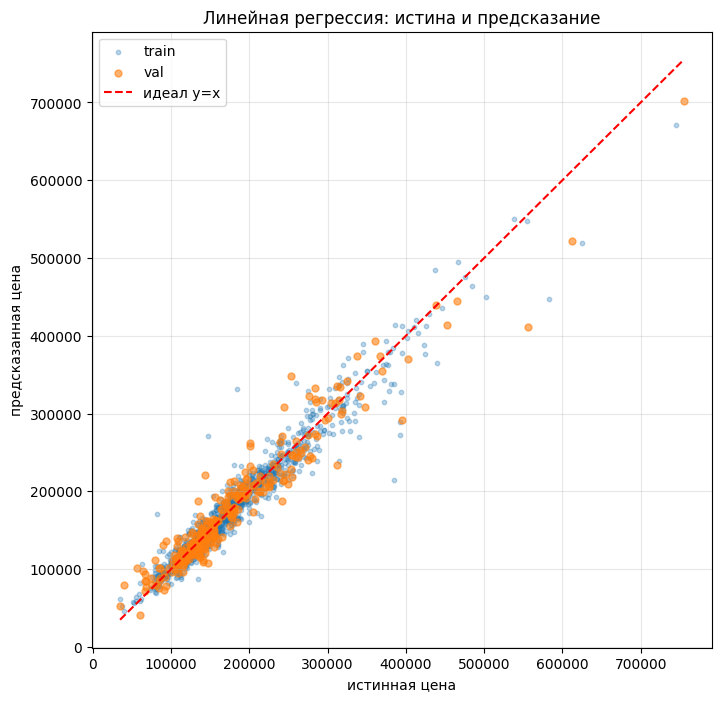

In [240]:
y_true_tr = np.exp(Y_train)
y_pred_tr = np.exp(pred_train)
y_true_val = np.exp(Y_val)
y_pred_val = np.exp(pred_val)

plt.figure(figsize=(8, 8))
plt.scatter(y_true_tr, y_pred_tr, alpha=0.3, s=10, label='train')
plt.scatter(y_true_val, y_pred_val, alpha=0.6, s=25, label='val')

lo = min(y_true_tr.min(), y_true_val.min())
hi = max(y_true_tr.max(), y_true_val.max())
plt.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='идеал y=x')

plt.xlabel('истинная цена')
plt.ylabel('предсказанная цена')
plt.title('Линейная регрессия: истина и предсказание')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [241]:
from sklearn.ensemble import RandomForestRegressor
model_forest=RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, max_depth=15, min_samples_leaf=3,max_features=1.0)
model_forest.fit(X_train,Y_train)

pred_train_forest=model_forest.predict(X_train)
pred_val_forest=model_forest.predict(X_val)

score(Y_train,pred_train_forest)
score(Y_val, pred_val_forest)
print(f"RMSLE: {rmsle_score(np.exp(Y_train), np.exp(pred_train_forest))}")
print(f"RMSLE: {rmsle_score(np.exp(Y_val), np.exp(pred_val_forest))}")

mae  8072.814055534442 
 rmse  14901.264380913615 
 r2  0.9663546924733253
mae  16736.380659063543 
 rmse  29389.212305195964 
 r2  0.890247315649264
RMSLE: 0.07161670912820611
RMSLE: 0.1431116417872393


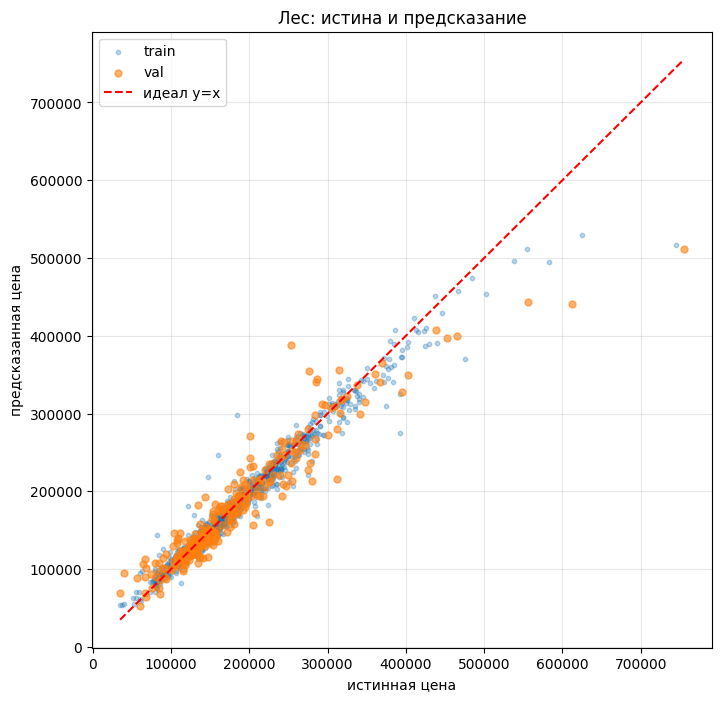

In [242]:
y_true_tr = np.exp(Y_train)
y_pred_tr = np.exp(pred_train_forest)
y_true_val = np.exp(Y_val)
y_pred_val = np.exp(pred_val_forest)

plt.figure(figsize=(8, 8))
plt.scatter(y_true_tr, y_pred_tr, alpha=0.3, s=10, label='train')
plt.scatter(y_true_val, y_pred_val, alpha=0.6, s=25, label='val')

lo = min(y_true_tr.min(), y_true_val.min())
hi = max(y_true_tr.max(), y_true_val.max())
plt.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='идеал y=x')

plt.xlabel('истинная цена')
plt.ylabel('предсказанная цена')
plt.title('Лес: истина и предсказание')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [243]:
from sklearn.ensemble import HistGradientBoostingRegressor

model_gbdt=HistGradientBoostingRegressor(learning_rate=0.05, max_iter=200, max_leaf_nodes=35, min_samples_leaf=20, l2_regularization=0.9,  random_state=42)
model_gbdt.fit(X_train, Y_train)
pred_train_gbdt=model_gbdt.predict(X_train)
pred_val_gbdt=model_gbdt.predict(X_val)
score(Y_train, pred_train_gbdt)
score(Y_val, pred_val_gbdt)
print(f"RMSLE: {rmsle_score(np.exp(Y_train), np.exp(pred_train_gbdt))}")
print(f"RMSLE: {rmsle_score(np.exp(Y_val), np.exp(pred_val_gbdt))}")

mae  4297.152551259897 
 rmse  8569.312067364644 
 r2  0.9895906721214395
mae  16494.07551565823 
 rmse  29995.119018855275 
 r2  0.8911417346390953
RMSLE: 0.03983481970375689
RMSLE: 0.14252731840268454


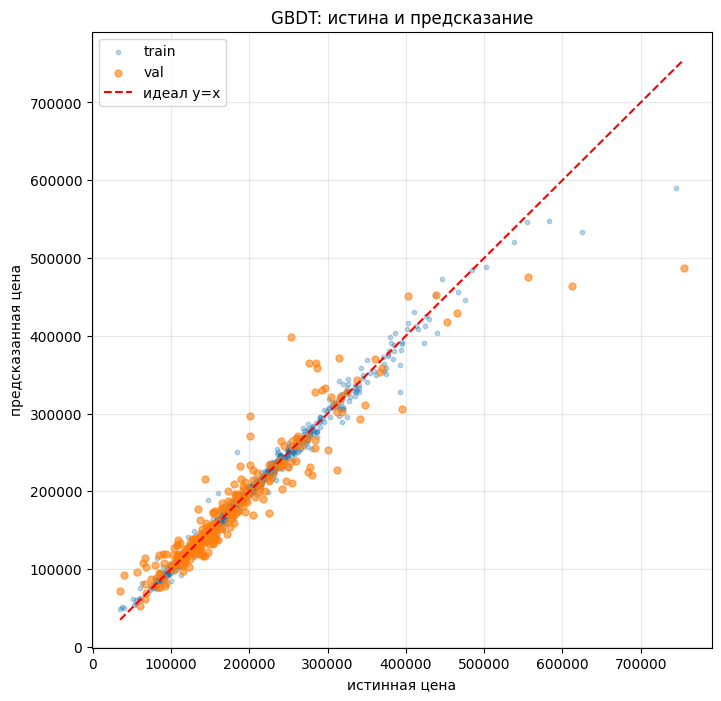

In [244]:
y_true_tr = np.exp(Y_train)
y_pred_tr = np.exp(pred_train_gbdt)
y_true_val = np.exp(Y_val)
y_pred_val = np.exp(pred_val_gbdt)

plt.figure(figsize=(8, 8))
plt.scatter(y_true_tr, y_pred_tr, alpha=0.3, s=10, label='train')
plt.scatter(y_true_val, y_pred_val, alpha=0.6, s=25, label='val')

lo = min(y_true_tr.min(), y_true_val.min())
hi = max(y_true_tr.max(), y_true_val.max())
plt.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='идеал y=x')

plt.xlabel('истинная цена')
plt.ylabel('предсказанная цена')
plt.title('GBDT: истина и предсказание')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [245]:
#блендинг моделей (линейная лучше предсказывает цены на очень дорогих домах, а gbdt лучше предсказывает на среднем диапазоне)
res_lin=Y_val-pred_val
res_gb=Y_val-pred_val_gbdt
print(np.corrcoef(res_lin, res_gb)[0,1])

0.8076757806342196


In [246]:
for w in [ 0.5, 0.6,0.7,0.8,0.9]:   # w — вес линейки
    blend = w * pred_val_lasso + (1 - w) * pred_val_gbdt
    print(f"w = {w}")
    score(Y_val, blend)
    print(f"RMSLE: {rmsle_score(np.exp(Y_val), np.exp(blend))}")

w = 0.5
mae  14937.2981497755 
 rmse  25029.389205641724 
 r2  0.907997157163959
RMSLE: 0.13102912986249185
w = 0.6
mae  14840.881549202015 
 rmse  24406.04704171686 
 r2  0.909502627291217
RMSLE: 0.1299526718172673
w = 0.7
mae  14818.544491806202 
 rmse  23943.547373694968 
 r2  0.9103862259592367
RMSLE: 0.1293167012208551
w = 0.8
mae  14917.750658246165 
 rmse  23658.32222786174 
 r2  0.9106479531680178
RMSLE: 0.129127726615726
w = 0.9
mae  15065.055617495 
 rmse  23565.16551732944 
 r2  0.9102878089175612
RMSLE: 0.12938770657387588


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

X_full = data.drop(columns=['SalePrice'])
Y_full = np.log(data['SalePrice'])

scaler_full = StandardScaler()
X_full_sc = scaler_full.fit_transform(X_full)


lasso_final = LassoCV(alphas=[0.001, 0.01, 0.1], cv=5, max_iter=10000, random_state=42)
lasso_final.fit(X_full_sc, Y_full)


model_gbdt_full = HistGradientBoostingRegressor(
    learning_rate=0.05, 
    max_iter=200, 
    max_leaf_nodes=35, 
    min_samples_leaf=20, 
    l2_regularization=0.9, 
    random_state=42
)
model_gbdt_full.fit(X_full, Y_full)



pred_lin_test_log = lasso_final.predict(scaler_full.transform(test))
pred_gbdt_test_log = model_gbdt_full.predict(test)

w_lin = 0.55
w_gbdt = 1.0 - w_lin

pred_test_log = w_lin * pred_lin_test_log + w_gbdt * pred_gbdt_test_log


pred_test_dollars = np.exp(pred_test_log)


original_test = pd.read_csv('test.csv')

submission = pd.DataFrame({
    'Id': original_test['Id'],
    'SalePrice': pred_test_dollars
})


submission.to_csv('submission.csv', index=False)

print("\nГОТОВО! Файл 'submission.csv' успешно сохранен.")
print("\nПервые 5 строк вашего сабмита:")
print(submission.head())
print(f"\nДиапазон предсказанных цен: ${pred_test_dollars.min():.0f} - ${pred_test_dollars.max():.0f}")
print(f"Количество строк: {len(submission)} (должно быть 1459)")


ГОТОВО! Файл 'submission.csv' успешно сохранен.

Первые 5 строк вашего сабмита:
     Id      SalePrice
0  1461  114832.519120
1  1462  151295.353929
2  1463  173602.452511
3  1464  189764.929199
4  1465  197325.285269

Диапазон предсказанных цен: $53500 - $881673
Количество строк: 1459 (должно быть 1459)
